# Lab 7 - Amanda Chang

### Lab 7 Prelab

In [24]:
import numpy as np

# Initialization Values
Vg = 18.00
Fs = 50000
Ts = 1/Fs

# Measured Values From Lab 6/LCR meter
V0 = 9.99
a = 7/9
D = 0.384236
alpha = 0.630819
L_m = 1.980557814607988e-05
Ipk = 6.816
L_leakage = 0.00039e-3

In [25]:
import pandas as pd
import csv
import math
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks
pd.set_option('display.float_format', lambda x: '%e' % x)

TITLE_FONTSIZE = 14
AXES_FONTSIZE = 12

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

def plot_1ch_peaks(filepath, title, channel='CH1', chlabel="Vdrain (V)", x1=None, x2=None):
    """
    Reads Rigol CSV data, applies a rolling average filter, and plots peaks within a specified range.

    Parameters
    ----------
    filepath : str
        The name of the CSV file (without extension) located in the 'data/' directory.
    title : str
        The title to display at the top of the plot.
    ch1label : str, optional
        Label for the Y-axis and the data series, by default "Shunt Voltage (Vsh)".
    x1 : float, optional
        The start time (X-axis) for peak detection. If None, no peaks are calculated.
    x2 : float, optional
        The end time (X-axis) for peak detection. If None, no peaks are calculated.

    Returns
    -------
    numpy.ndarray
        An Nx2 matrix where the first column contains peak timestamps and the 
        second column contains the corresponding peak values. Returns an empty 
        array if no peaks are found or if x1/x2 are not provided.
    yay i love when AI writes my docstrings. credit to gemini for this docstring
    """
    data, t0, dT = read_rigol_csv("data/"+filepath+".csv")
    fig, ax = plt.subplots(figsize=(10, 2.5))
    data[channel] = data[channel].rolling(10, min_periods=1, center=True).mean()
    data.plot(x="X", y=channel, ax=ax, label=chlabel, legend=False, color='black')

    peak_matrix = np.array([])
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        indices, _ = find_peaks(subset[channel], height=0, distance=10, prominence=0.1)
        
        peak_times = subset['X'].iloc[indices].values
        peak_values = subset[channel].iloc[indices].values
        peak_matrix = np.column_stack((peak_times, peak_values))
        
        ax.plot(peak_times, peak_values, ".", color="red", label='Peaks')

    ax.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax.set_ylabel(chlabel, fontsize=AXES_FONTSIZE, color='#f74519')
    
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.tight_layout()
    plt.show()

    return peak_matrix

#### Step 1: Determine $\omega_d$ and $\zeta$ from inspecting waveform

Last lab, I also calculated the damped natural frequency ($f_d$) and damping ratio ($\zeta$) by identifying peaks and performing calculations based on the logarithmic decrement equation:

$$\delta = \frac{1}{n} \ln \left| \frac{x_1}{x_{n+1}} \right|$$

and the damping ratio equation:

$$\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}$$

*Previously, I forgot to subtract the equilibrium values from my peaks and was thus calculating these values from zero. This means my damped natural frequency values were correct, but that my damping ratio values were extremely off. I corrected this error and also used linear regression to include all intermediate peaks instead of just the first and last selected. Additionally, I selected peaks later in the oscillation period for the fast oscillations. This is because the beginning of the noise wave contains more non-linear behavior than the end of it, which approximates a 2nd order system more accurately. Thus, calculations of zeta and frequency less affected by non-linear behavior towards the end of the wave.*

After going back and modifying those things for $\omega_d$ and $\zeta$ calculations, I got the following results:

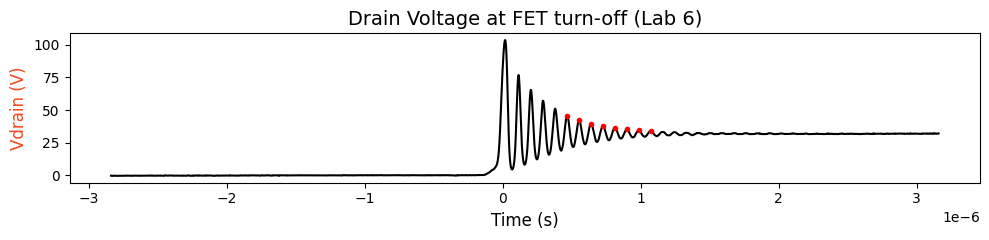

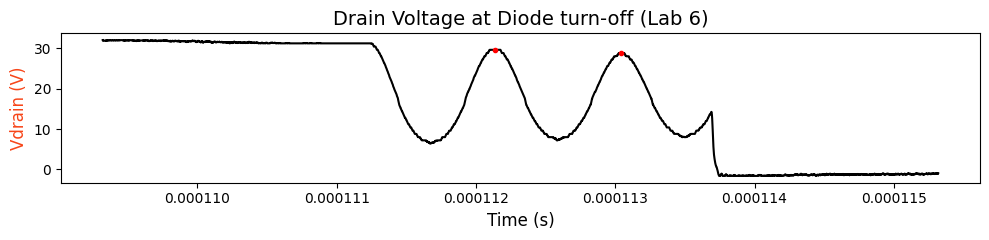

In [26]:
peaks_fetoff_lab6 = plot_1ch_peaks("10vq4_lab6", "Drain Voltage at FET turn-off (Lab 6)", x1=0.45e-6, x2=1.1e-6)
peaks_diodeoff_lab6 = plot_1ch_peaks("10vq5_lab6", "Drain Voltage at Diode turn-off (Lab 6)", x1=0.000111, x2=0.0001135)

In [57]:
# This is my new oscillation analysis function, which gives much more reasonable values for zeta than before.
def analyze_oscillations_robust(peak_matrix, equilibrium):
    peak_matrix = np.asarray(peak_matrix)
    if peak_matrix.ndim < 2 or len(peak_matrix) < 2:
        return 0.0, 0.0

    times = peak_matrix[:, 0]
    amplitudes = np.abs(peak_matrix[:, 1] - equilibrium)

    avg_period = np.mean(np.diff(times))
    # changed it to damped angular natural frequency from just damped natural frequency
    wd = 2*np.pi / avg_period if avg_period > 0 else 0.0

    n = np.arange(len(amplitudes))
    ln_amplitudes = np.log(amplitudes)
    
    slope, intercept = np.polyfit(n, ln_amplitudes, 1)
    delta = -slope
    zeta = delta / np.sqrt(4 * np.pi**2 + delta**2)

    return wd, zeta # wo is approx. equal to wd when zeta is small
    
max_vdrain_10v = 32.2 # This value came from point selection on the full wave in the previous lab

wd_fet, zeta_fet = analyze_oscillations_robust(peaks_fetoff_lab6, max_vdrain_10v)
print(f"FET OFF: Damped Angular Natural Frequency: {wd_fet:.2f} Hz, Damping Ratio: {zeta_fet:.4f}")
wd_diode, zeta_diode = analyze_oscillations_robust(peaks_diodeoff_lab6, Vg)
print(f"DIODE OFF: Damped Angular Natural Frequency: {wd_diode:.2f} Hz, Damping Ratio: {zeta_diode:.4f}")

FET OFF: Damped Angular Natural Frequency: 72698011.82 Hz, Damping Ratio: 0.0458
DIODE OFF: Damped Angular Natural Frequency: 6919807.61 Hz, Damping Ratio: 0.0114


#### Step 2: Measure/Calculate L and C assuming $\zeta << 1$

`L_leakage` above represents the sum of the parasitic inductances $L_{\sigma1}$ and $L_{\sigma2'}$ and was determined by shorting the secondary side of the transformer and measuring the inductance across the primary side using the LCR meter. This works because when the secondary side is shorted, the transformer can be modeled as a single loop with the two parasitic inductances in series.

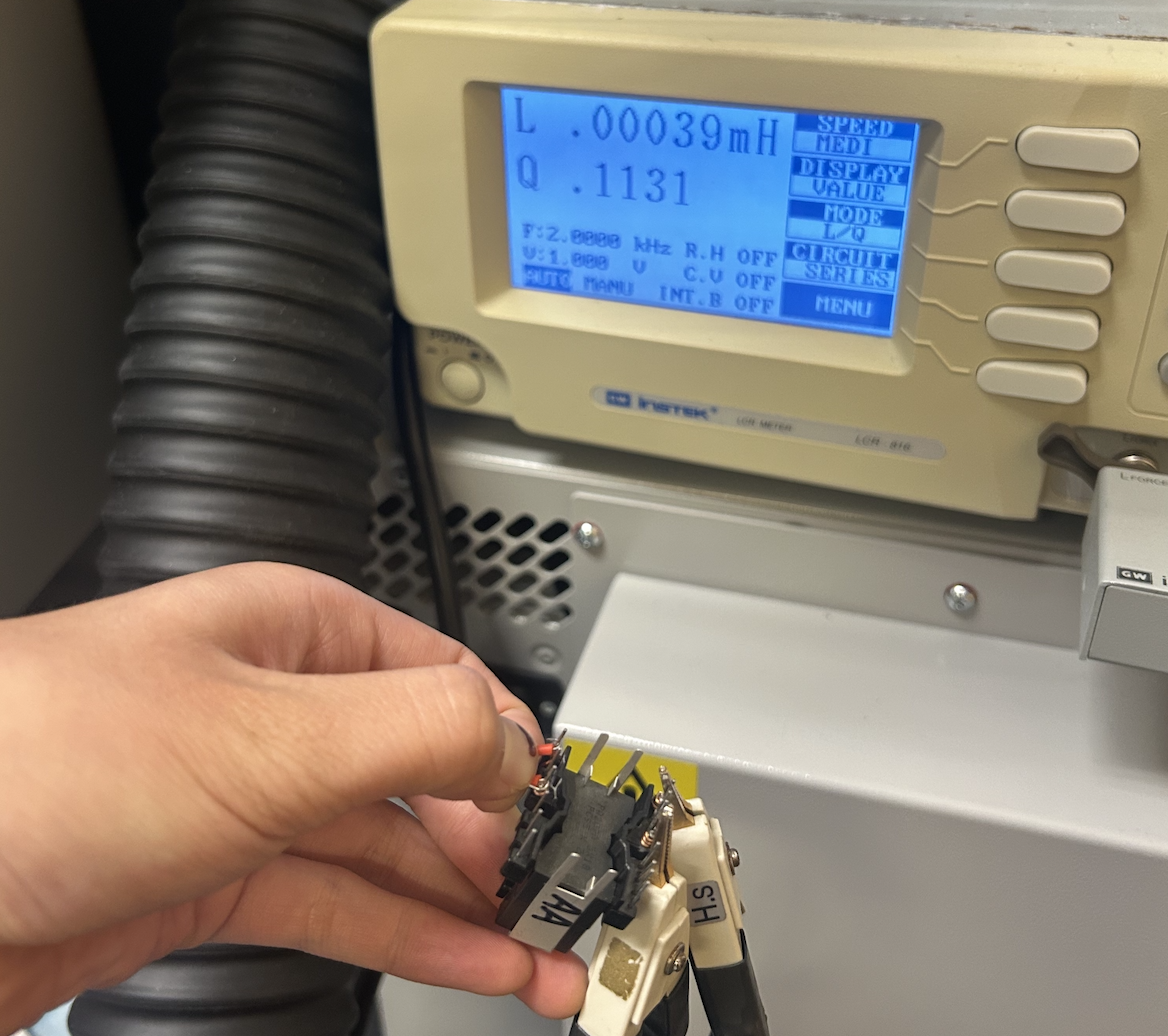

When the MOSFET is off and the diode is still on, from an AC current's perspective the circuit can be modeled as a series LC circuit where the inductance is equal to the sum of the parasitic inductances on the primary and secondary sides and the capacitance is equal to the parasitic capacitances in parallel.

This is because the current can be modeled as passing through the parasitic inductance on the primary and secondary sides in series, since the magnetizing inductance is much larger than the parasitic inductance. The path through the two series parasitic inductances is much lower impedance than the magnetizing inductance, so we can essentially eliminate $L_m$ from the circuit. 

The parasitic capacitances can be modeled as a single equivalent capacitor, because once you replace the voltage sources with short circuits and the MOSFET with only its parasitic capacitance, all of them are in parallel. This capacitance is itself in series with the parsitic inductance. Therefore, the following equation applies.

$$\omega_{o(\text{fet})} = \frac{1}{\sqrt{L_{\text{leakage}} \cdot C_p}}$$

We can then isolate for our equivalent parasitic capacitance $C_p$. Another important note is that based on our assumption that $\zeta << 1$, $\omega_{o} \approxeq \omega_d$. Implementing those two changes gives us the following equation to evaluate $C_p$ by:
$$C_p = \frac{1}{L_{leakage} \cdot \omega_{o(\text{fet})}^2}$$

In [28]:
C_p = 1/(L_leakage * wd_fet**2)
print(f"Parasitic Capacitance: {C_p*1e12:.2f} pF")
print(f"Parasitic Capacitance: {C_p} F")

Parasitic Capacitance: 485.17 pF
Parasitic Capacitance: 4.851659634051112e-10 F


#### Step 3/4: Select $C_{sb}$ and $R_{sb}$

A general rule of thumb says that our snubber capacitance should be three times that of our parasitic capacitance. Additionally, for $C_{sb} >> C_p$, we can use the following equation to calculate our snubber resistance $R_{sb}$, because the parasitic capacitances are in parallel with our snubber circuit. For the fast oscillation, the inductance in this model is the sum of the leakage inductances `L_leakage`. For the slow oscillation (diode and fet both off), the inductance is instead the sum of `L_m` and the $L_{\sigma1}$, which we can approximate as being half of `L_leakage`. This is because the diode being off removes the low impedance path of $L_{\sigma2}$ for the energy to travel through, which forces the noise to go through the main magnetizing inductance instead. The winding resistance, while present, can be ignored for both if we assume that $R_{sb} >> R_w$.

$$\zeta \approxeq \frac{R_{sb}}{2} \sqrt{\frac{C_{sb}}{L}}$$

Since we know our goal $\zeta$ is 0.7, we can isolate $R_{sb}$ like so:

$$R_{sb} = 2\zeta \sqrt{\frac{L}{C_{sb}}}$$

In [29]:
C_sb = C_p*3
zeta = 0.7
R_sb_fast = 2*zeta*math.sqrt(L_leakage/C_sb)
R_sb_slow = 2*zeta*math.sqrt((L_m+L_leakage/2)/C_sb)

print(f"Snubber Capacitance: {C_sb*1e9:.2f} nF")
print(f"High Frequency Snubber Resistance: {R_sb_fast:.2f} Ohms")
print(f"Lower Frequency Snubber Resistance: {R_sb_slow:.2f} Ohms")

Snubber Capacitance: 1.46 nF
High Frequency Snubber Resistance: 22.92 Ohms
Lower Frequency Snubber Resistance: 164.11 Ohms


Looking into our list of available components, the best picks for the FET off/high frequency noise are:

**1.5 nF** capacitor, **22 $\Omega$** resistor

However, the low frequency resistor value is relatively far away from any of the available resistors. To pick the best one, I back-calculated the actual $\zeta$ based on the two closest resistor values to see how close it would be to our desired 0.7.

In [60]:
C_sb_real = 1.54e-9
zeta_fet_22R = 22/2 * math.sqrt(C_sb_real/(L_leakage))
zeta_fet_100R = 100/2 * math.sqrt(C_sb_real/(L_leakage))
print("22 ohm fet off R_sb:")
print(f"zeta: {zeta_fet_22R:.2f}")

print("100 ohm fet off R_sb:")
print(f"zeta: {zeta_fet_100R:.2f}\n")

zeta_diode_100R = 100/2 * math.sqrt(C_sb_real/(L_m+L_leakage/2))
zeta_diode_220R = 220/2 * math.sqrt(C_sb_real/(L_m+L_leakage/2))
print("100 ohm diode off R_sb:")
print(f"zeta: {zeta_diode_100R:.2f}")

print("220 ohm diode off R_sb:")
print(f"zeta: {zeta_diode_220R:.2f}")

22 ohm fet off R_sb:
zeta: 0.69
100 ohm fet off R_sb:
zeta: 3.14

100 ohm diode off R_sb:
zeta: 0.44
220 ohm diode off R_sb:
zeta: 0.97


From here I picked the **1.5 nF** capacitor and **220 $\Omega$** resistor for the low frequency values, since the 220 $\Omega$ resistor is nearly critically damped and the 100 $\Omega$ resistor is very underdamped.  

### RCD Clamp Calculations

In [31]:
# # I would pick 2200 Ohm and 68 nF if I could do it again
# Vcp = V0/a + Vg + 6

# Wcp = (1/2)*(Ipk**2)*(L_leakage)*Vcp/(Vcp-V0)
# Pcp = Wcp/Ts
# Rcp = Vcp**2 / Pcp

# delta = 0.135 # 10-20% ripple
# Ccp = 1/(Rcp*delta)*(Ts-Ipk*(L_leakage)/(Vcp-V0))

# print(f"Clamp Voltage (Vcp): {Vcp:.2f} V")
# print(f"Energy Dissipated: {Wcp*1e6:.2f} uJ")
# print(f"Power Dissipated: {Pcp:.2f} W")
# print(f"Clamp Resistance: {Rcp:.2f} Ohms")
# print(f"Clamp Capacitance: {Ccp*1e9:.2f} nF\n")


Vcp = V0/a + Vg + 13.15

Wcp = (1/2)*(Ipk**2)*(L_leakage)*Vcp/(Vcp-V0)
Pcp = Wcp/Ts
Rcp = Vcp**2 / Pcp

delta = 0.1256 # 10-20% ripple
Ccp = 1/(Rcp*delta)*(Ts-Ipk*(L_leakage)/(Vcp-V0))

print(f"Clamp Voltage (Vcp): {Vcp:.2f} V")
print(f"Energy Dissipated: {Wcp*1e6:.2f} uJ")
print(f"Power Dissipated: {Pcp:.2f} W")
print(f"Clamp Resistance: {Rcp:.2f} Ohms")
print(f"Clamp Capacitance: {Ccp*1e9:.2f} nF")

Clamp Voltage (Vcp): 36.84 V
Energy Dissipated: 12.43 uJ
Power Dissipated: 0.62 W
Clamp Resistance: 2184.34 Ohms
Clamp Capacitance: 67.49 nF

Clamp Voltage (Vcp): 43.99 V
Energy Dissipated: 11.72 uJ
Power Dissipated: 0.59 W
Clamp Resistance: 3302.68 Ohms
Clamp Capacitance: 48.03 nF


After adjusting my ripple and Vcp values to acceptable levels that would match a set of discrete components, I settled on a **3300 $\Omega$** resistor and a **47 nF** capacitor for my clamp circuit.

### Plotting Functions

In [32]:
def get_channel_data(data, channel_name):
    if channel_name in data.columns:
        #return data[channel_name].rolling(10, min_periods=1, center=True).mean()
        return data[channel_name]
    return None

def analyze_rigol_data(data, has_ch1, has_ch2, x1, x2, drainx):
    slope, ch2_mean, peak_vsh, max_vdrain = None, None, None, None
    
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        
        if has_ch1 and not subset.empty:
            result = linregress(subset['X'], subset['CH1'])
            slope = float(result.slope)
            peak_vsh = float(data.iloc[(data['X'] - x2).abs().argsort()[:1]]['CH1'].values[0])

        if has_ch2:
            ch2_mean = float(subset['CH2'].mean())
            max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
    elif has_ch2:
        max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
            
    return slope, ch2_mean, peak_vsh, max_vdrain

In [33]:
def plot_rigol(
    filepath, 
    title, 
    ch1label="Shunt Voltage (Vsh)", 
    ch2label="Drain Voltage (Vd)", 
    ch3label="Cathode Voltage (Vk)", 
    x1=None, 
    x2=None, 
    duty_points=None, 
    drainx=0.5e-5
): 
    data, t0, dT = read_rigol_csv(f"data/{filepath}.csv")
    
    channels = {
        'CH1': {'label': ch1label, 'color': '#0072BD', 'axis': 0},
        'CH2': {'label': ch2label, 'color': '#f74519', 'axis': 1},
        'CH3': {'label': ch3label, 'color': '#FFBF00', 'axis': 1}
    }

    for ch in channels:
        smoothed = get_channel_data(data, ch)
        if smoothed is not None:
            data[ch] = smoothed

    slope, ch2_mean, peak_vsh, max_vdrain = analyze_rigol_data(
        data, 'CH1' in data, 'CH2' in data, x1, x2, drainx
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]
    
    handles, labels = [], []

    for ch, config in channels.items():
        if ch not in data:
            continue
            
        ax = axes[config['axis']]
        ln, = ax.plot(data['X'], data[ch], label=config['label'], color=config['color'], alpha=0.9)
        
        handles.append(ln)
        labels.append(config['label'])

    if 'CH1' in data and x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        fit = slope * subset['X'] + (peak_vsh - slope * x2)
        ax1.plot(subset['X'], fit, color="red", lw=2, ls="--", label='Linear Fit')
        ax1.plot(x2, peak_vsh, 'r*', markersize=10)

    if 'CH2' in data and duty_points is not None:
        for px in duty_points:
            idx = (data['X'] - px).abs().idxmin()
            py = data.loc[idx, 'CH2']
            ax2.plot(px, py, 'ko', mfc='none', markersize=6)

    ax1.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax1.set_ylabel(ch1label, color=channels['CH1']['color'], fontsize=AXES_FONTSIZE)
    
    if 'CH3' in data:
        ax2.set_ylabel(f"{ch2label} / {ch3label}", color='#FB820D', fontsize=AXES_FONTSIZE)
    else:
        ax2.set_ylabel(f"{ch2label}", color=channels['CH2']['color'], fontsize=AXES_FONTSIZE)
    
    ax1.legend(handles, labels, loc='upper left', frameon=True)
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.tight_layout()
    plt.show()
    return (slope, ch2_mean, peak_vsh, max_vdrain)

### Q2: Plot Baselines
$V_{obl} = 8.99V$ 

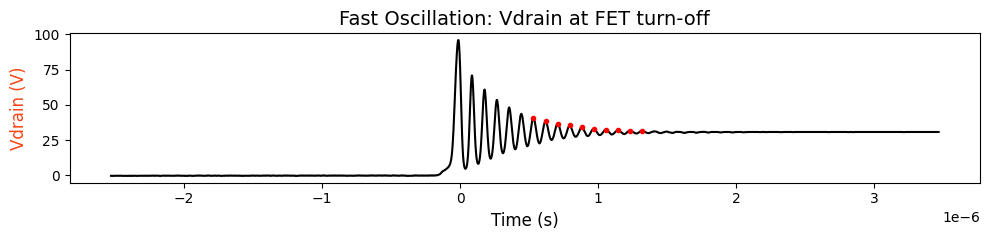

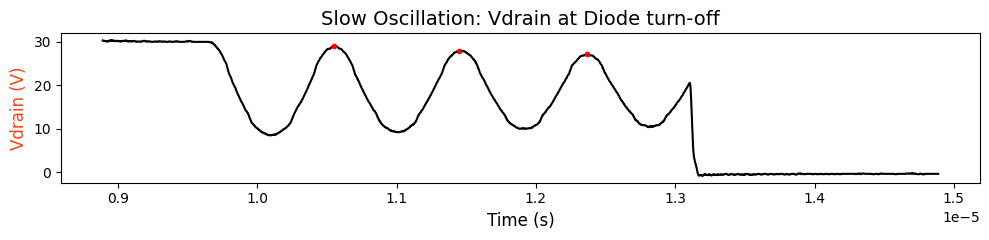

In [54]:
Vobl = 8.99
peaks_fetoff = plot_1ch_peaks("8_99v_f", "Fast Oscillation: Vdrain at FET turn-off", channel='CH2', x1=0.45e-6, x2=1.4e-6)
peaks_diodeoff = plot_1ch_peaks("8_99v_s", "Slow Oscillation: Vdrain at Diode turn-off", channel='CH2', x1=1e-5, x2=1.25e-5)

Note here that I have chosen peaks later in the oscillation period for the fast oscillations. This is because the beginning of the noise wave contains more non-linear behavior than the end of it, which approximates a 2nd order system more accurately. Thus, calculations of zeta and resonant frequency values for Q9 are less affected by non-linear behavior towards the end of the wave.

### Q3: Fast RC Snubber Vsh & Vd

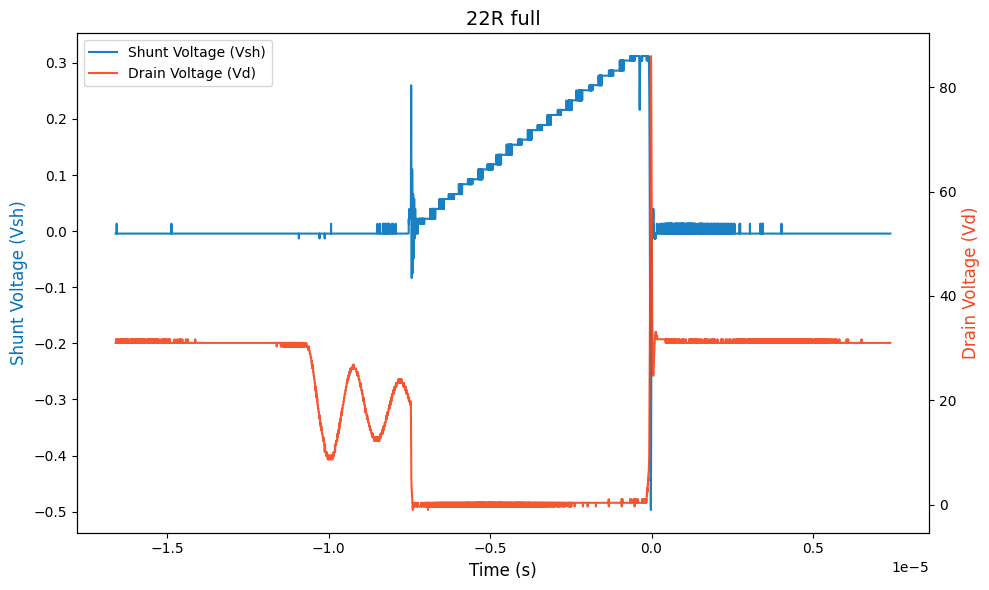

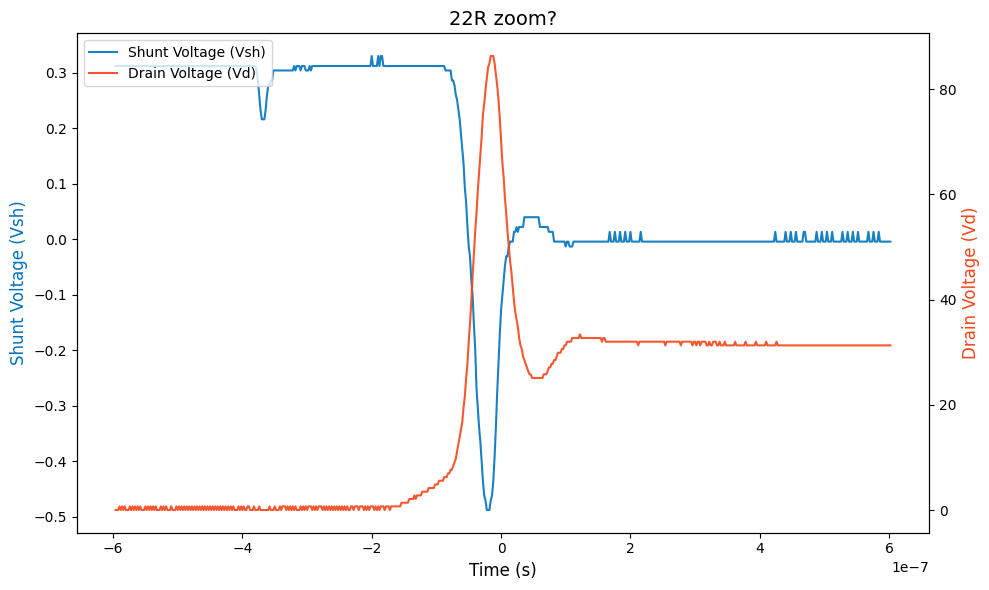

In [35]:
_ = plot_rigol("22R_q4_full", "22R full")
steady_vdrain_q3 = plot_rigol("22R_q4_hfzoom", "22R zoom?", drainx=4e-7)[3]

### Q4: Slow RC Snubber Vsh & Vd

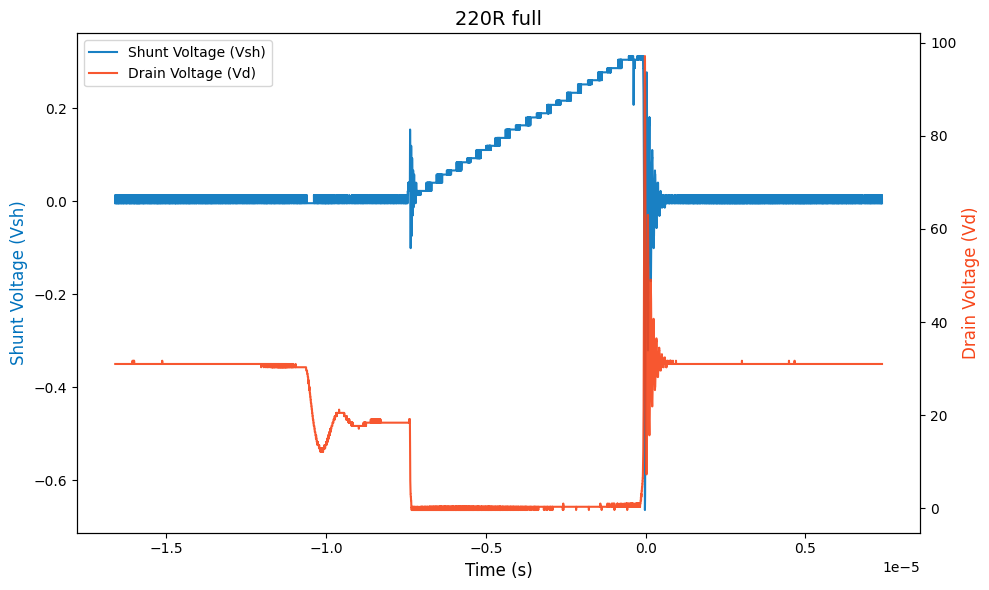

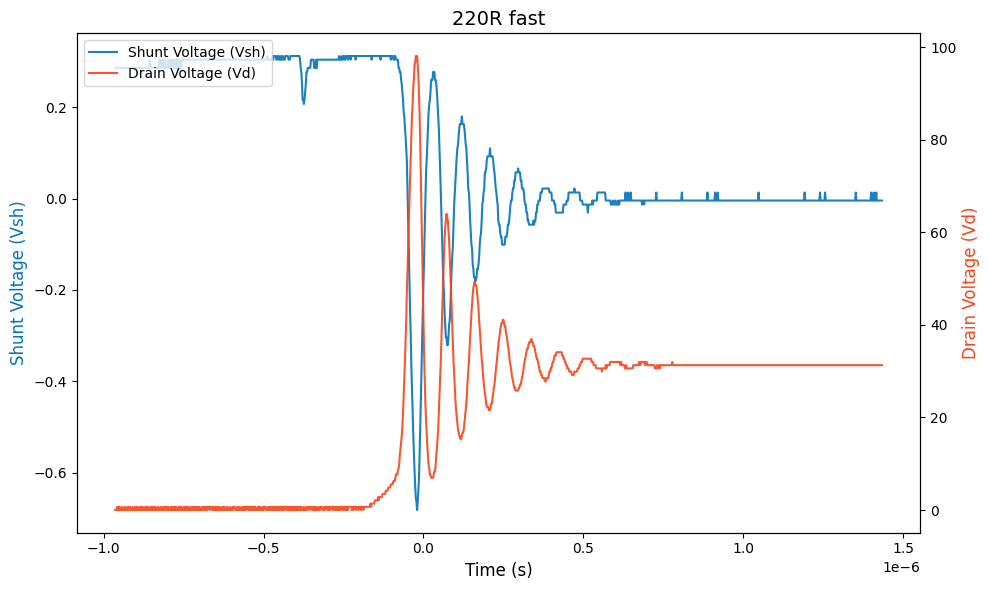

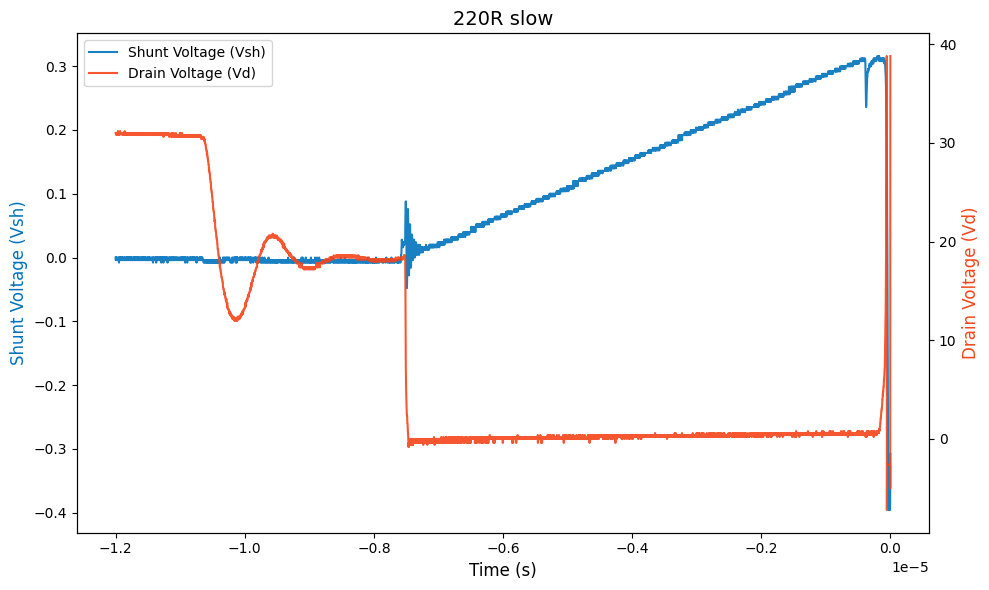

In [36]:
_ = plot_rigol("220R_q4_full", "220R full")
_ = plot_rigol("220R_q4_fast", "220R fast")
_ = plot_rigol("220R_q4_slow", "220R slow")

### Q5: RCD clamp testing

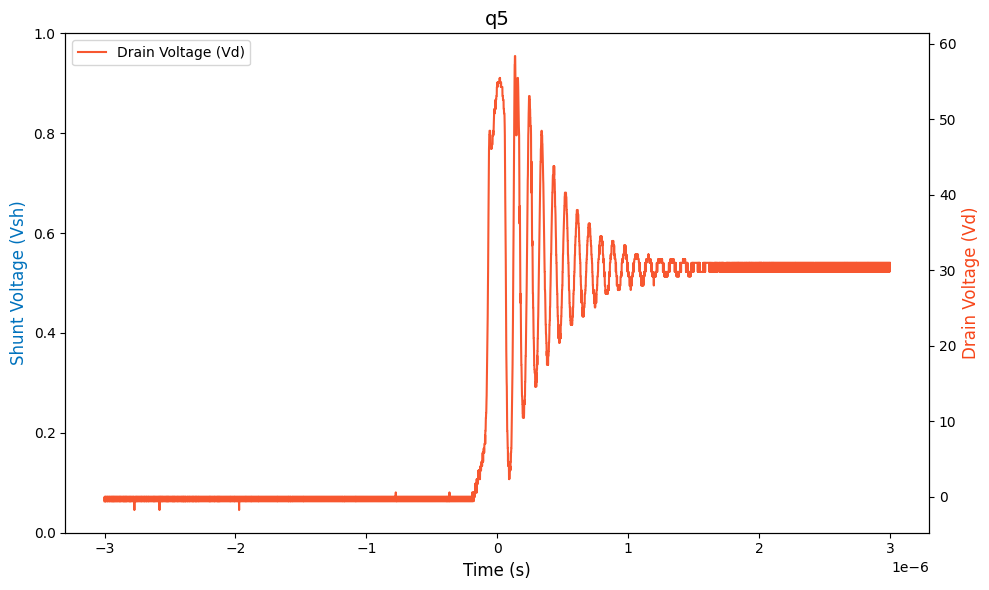

In [37]:
_ = plot_rigol("8_99v_q5", "q5")

Yes, the clamp is doing its job. We can see in the plot above that the peak of the drain voltage is less than 60V while the baseline peak drain voltage is at 100V. From this, we know that this is acceptable for our MOSFET rated for 60V.

<font color='red' size='6'><b>TODO</b></font>

### Q7: Cathode voltage, shunt current and Vd plot

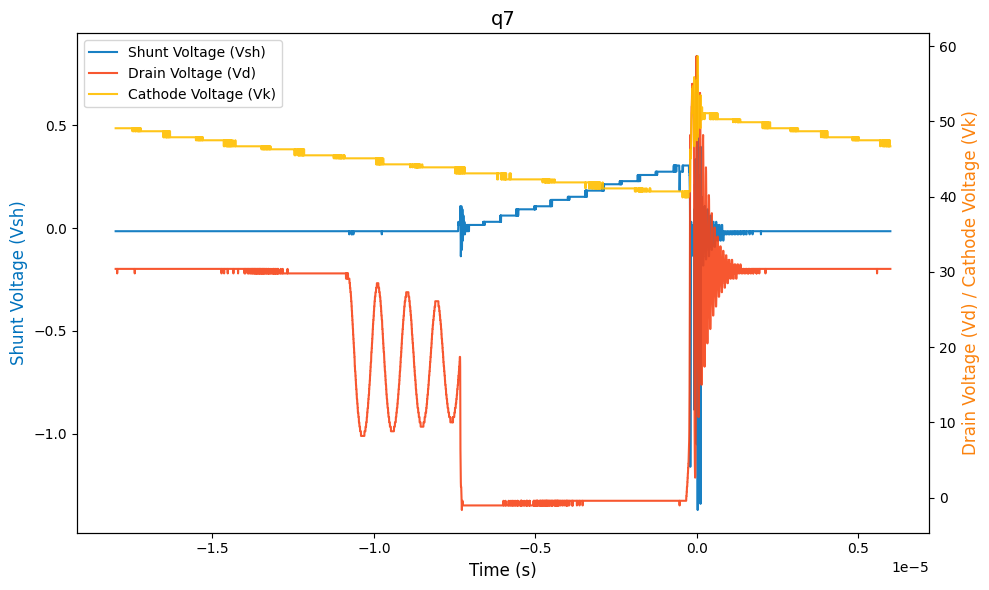

In [38]:
_ = plot_rigol("8_99v_q7", "q7")

### Q8: 10V output cathode voltage, shunt current and Vd plot

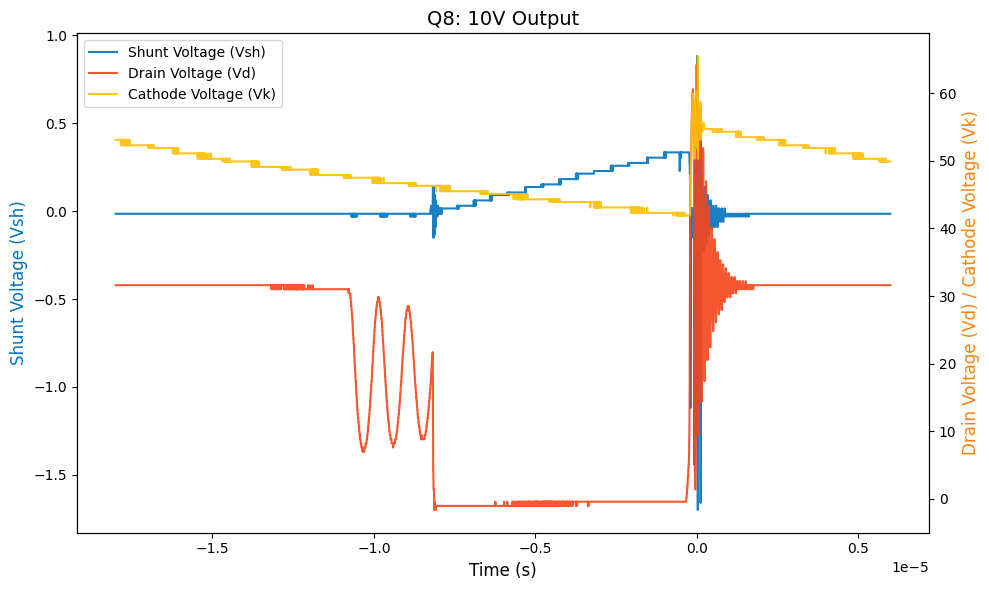

In [39]:
_ = plot_rigol("10v_q8","Q8: 10V Output")

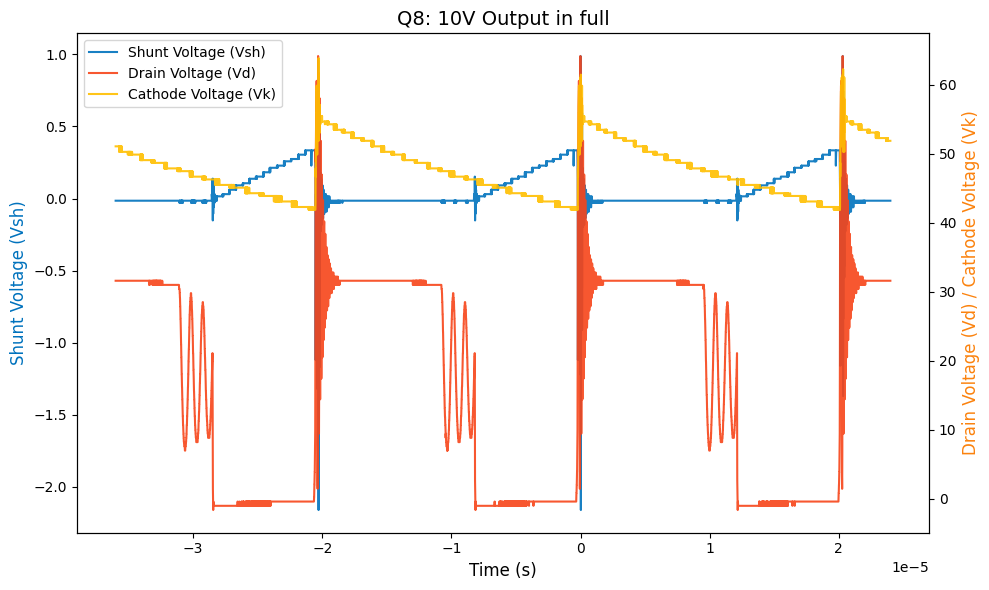

In [40]:
_ = plot_rigol("10v_q8_full", "Q8: 10V Output in full")

### TODO: CALC RESONANT FREQUENCY
### Q9: Determine fn & zeta of slow & fast oscillations

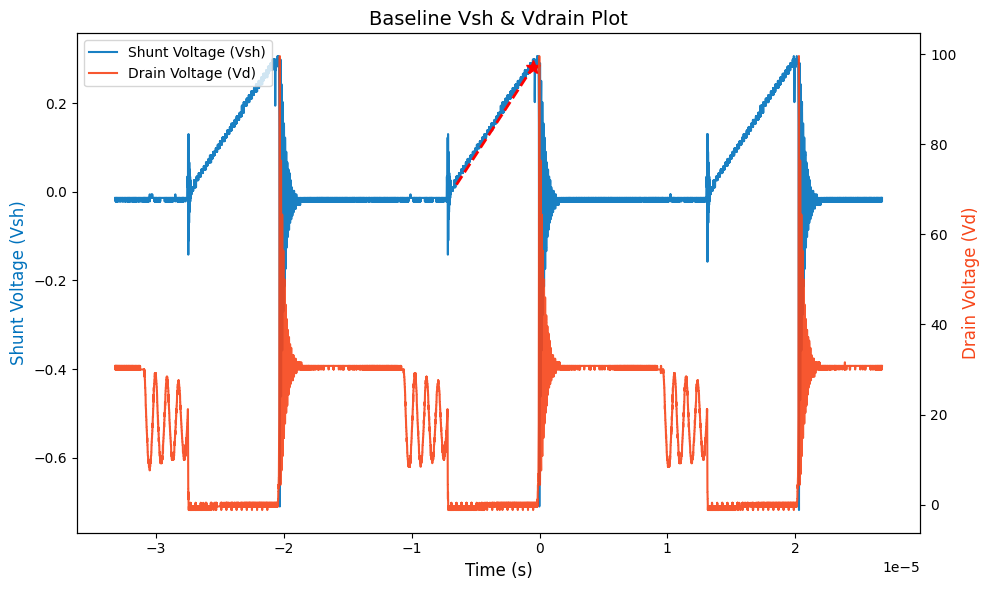

In [41]:
dvdt_bl, avg_vd_bl, peak_vsh_bl, max_vd_bl = plot_rigol("8_99v_full", "Baseline Vsh & Vdrain Plot", x1=-0.65e-5, x2=-0.05e-5, drainx=0.4e-5)

In [79]:
wd_fet, zeta_fet = analyze_oscillations_robust(peaks_fetoff, max_vd_bl)
print(f"Fast Oscillation -- Damped Angular Natural Frequency: {wd_fet:.2f} Hz, Damping Ratio (zeta): {zeta_fet:.4f}")
wd_diode, zeta_diode = analyze_oscillations_robust(peaks_diodeoff, Vg)
print(f"Slow Oscillation -- Damped Angular Natural Frequency: {wd_diode:.2f} Hz, Damping Ratio (zeta) : {zeta_diode:.4f}")

Fast Oscillation -- Damped Angular Natural Frequency: 71580592.11 Hz, Damping Ratio (zeta): 0.0482
Slow Oscillation -- Damped Angular Natural Frequency: 6904599.24 Hz, Damping Ratio (zeta) : 0.0158


### Q10: Confirm prep work LCR value estimates

### Q11: Resonant frequency comparison & explanation

### Q12: Analyze the performance of your fast RC snubber

A. Determine the dampened resonant frequency and damping ratio.

To calculate my zeta values for both the fast and slow RC snubbers without having enough peaks to perform the same analysis as I did on the baseline, I used the following relation. $M_p$ represents the percentage overshoot of the first peak relative to the steady state value.
$$\zeta = \frac{-\ln(M_p)}{\sqrt{\pi^2 + \ln^2(M_p)}}$$

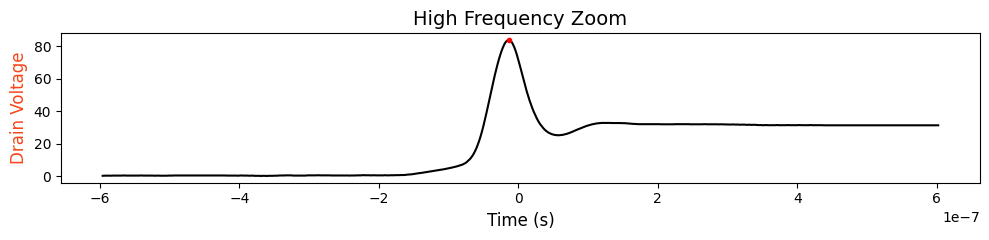

Percentage overshoot (Mp): 167.89%
Measured damping ratio (zeta): -0.16


In [76]:
peak_vd_22hf = plot_1ch_peaks("22R_q4_hfzoom", "High Frequency Zoom", channel='CH2', chlabel="Drain Voltage", x1=-0.5e-7, x2=1e-7)[0][1]
Mp_22fast = (peak_vd_22hf - steady_vdrain_q3)/steady_vdrain_q3

log_mp = np.log(abs(Mp_22fast)) 
zeta_22fast = -log_mp / np.sqrt(np.pi**2 + log_mp**2)

print(f"Percentage overshoot (Mp): {Mp_22fast:.2%}")
print(f"Measured damping ratio (zeta): {zeta_22fast:.2f}")

B. Did you meet the goal of Zeta = 0.7?

In [77]:
C_sb_modified = 3.3e-9
zeta_fet_22R = 22/2 * math.sqrt(C_sb_modified/(L_leakage))
print("22 ohm fet off R_sb:")
print(f"zeta: {zeta_fet_22R:.2f}")

22 ohm fet off R_sb:
zeta: 1.01


No, my zeta value is somehow -0.16, which is in a zone of instability and indicates that the circuit is somehow sourcing power, possibly from parasitic inductance. To adjust this in the future, I might increase my capacitance value to 3.3nF, even though it would theoretically raise my damping ratio to 1 just becuase it is so far below my expected damping ratio.

### Q13: Analyze the performance of your slow RC snubber

A. Determine the dampened resonant frequency and damping ratio.

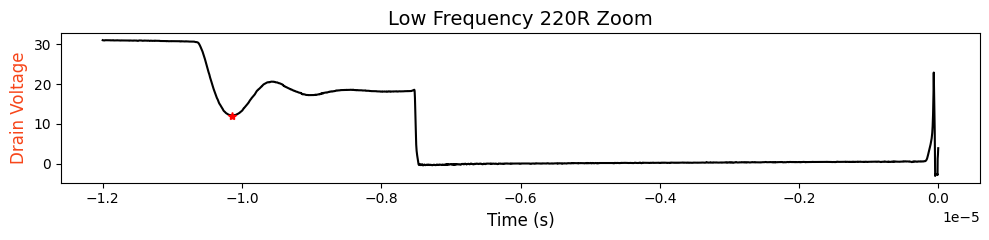

Percentage overshoot (Mp): -33.11%
Measured damping ratio (zeta): 0.33


In [78]:
def plot_1ch_troughs(filepath, title, channel='CH1', chlabel="Vdrain (V)", x1=None, x2=None):
    data, t0, dT = read_rigol_csv("data/"+filepath+".csv")
    fig, ax = plt.subplots(figsize=(10, 2.5))
    data[channel] = data[channel].rolling(10, min_periods=1, center=True).mean()
    data.plot(x="X", y=channel, ax=ax, label=chlabel, legend=False, color='black')

    trough_matrix = np.array([])
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        
        inverted_data = -subset[channel]
        
        indices, _ = find_peaks(inverted_data, distance=10, prominence=0.1)
        
        trough_times = subset['X'].iloc[indices].values
        trough_values = subset[channel].iloc[indices].values # Original voltage
        trough_matrix = np.column_stack((trough_times, trough_values))
        
        ax.plot(trough_times, trough_values, "*", color="red", label='Troughs')

    ax.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax.set_ylabel(chlabel, fontsize=AXES_FONTSIZE, color='#f74519')
    
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.tight_layout()
    plt.show()

    return trough_matrix

peak_vd_220lf = plot_1ch_troughs("220R_q4_slow", "Low Frequency 220R Zoom", channel='CH2', chlabel="Drain Voltage", x1=-1.1e-5, x2=-1e-5)[0][1]
Mp_220slow = (peak_vd_220lf - Vg)/Vg

log_mp = np.log(abs(Mp_220slow)) 
zeta_220slow = -log_mp / np.sqrt(np.pi**2 + log_mp**2)
print(f"Percentage overshoot (Mp): {Mp_220slow:.2%}")
print(f"Measured damping ratio (zeta): {zeta_220slow:.2f}")

B. Did you meet the goal of Zeta = 0.7?

In [70]:
C_sb_real = 1.54e-9
zeta_diode_220R = 220/2 * math.sqrt(C_sb_real/(L_m+L_leakage/2))

print("220 ohm diode off R_sb:")
print(f"zeta: {zeta_diode_220R:.2f}")

220 ohm diode off R_sb:
zeta: 0.97


My results show that my damping ratio is significantly below the 0.7 zeta goal, which is a bit mystifying considering that my 220$\Omega$ 1.5nF component combination should have yielded a 0.95 damping ratio according to my theoretical calculations above. Furthermore, the capacitor type that we used is C0G/NP0, which theoretically maintains the appropriate capacitor rating even at high voltages. On top of that, because of the lack of components over the weekend, I created an approximate 1.5nF capacitor by soldering two 3.3nF capacitors together in series. Upon measuring it with the LCR meter, I found that my franken-capacitor had a capacitance of 1.54nF. Incorporating that into my calculation pushes that damping ratio even further up towards 0.97, which really confuses me considering my actual damping ratio came out to only 0.33. It also even decreases the amount of voltage drop across each capacitor, which should improve its damping even more. I have no idea why it's so low! 

### Q14: Analyze the performance of your RCD clamp

A. Using the D6 cathode voltage measurement, and considering the input voltage, plot the voltage of C16 both for Vo = Vobl and Vo = 10V

B. Identify the D6 turn-on and turn-off events

C. Determine the peak and ripple of the C16 voltage

D. How much average power is dissipated by the RCD clamp?

E. Determine the (differential) capacitance of C16 based on the C16 voltage measurement

F. Do the waveforms match your digital twin simulations?